# Phase 1 - Modele A : Courbe de puissance de l'eolienne

Ce notebook construit un modele empirique + physique de `P(V)` a partir de `donnees.txt`.

Objectifs du notebook :
- Nettoyer les mesures et isoler l'eolienne en fonctionnement (`Statut = 1`)
- Visualiser le nuage de points `P` en fonction de `V`
- Estimer le rendement `eta` sur la plage utile
- Construire une courbe de puissance par binning avec incertitudes
- Superposer modele theorique et donnees
- Bonus : valider le modele en train/test (RMSE)

In [7]:
# Cellule 1 - Chargement et premier diagnostic
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 20)

chemin_donnees = Path("donnees.txt")
assert chemin_donnees.exists(), f"Fichier introuvable : {chemin_donnees}"

df_brut = pd.read_csv(chemin_donnees, sep=r"\s+", engine="python")

df_brut = df_brut.rename(
    columns={
        "Vitess_Vent_[m/s]": "vitesse_vent_ms",
        "Dir_Vent_[deg]": "direction_vent_deg",
        "Pelec[w]": "puissance_w",
        "Patm[Pa]": "pression_pa",
        "Temp[degC]": "temperature_c",
        "Statut": "statut",
    }
)

print("Taille brute :", df_brut.shape)
display(df_brut.head())
display(df_brut.describe(include="all"))

df = df_brut[df_brut["statut"] == 1].copy()

print("\nTaille apres filtre (statut = 1) :", df.shape)
print("Points ecartes (maintenance / arret) :", len(df_brut) - len(df))

Taille brute : (19918, 6)


,vitesse_vent_ms,direction_vent_deg,puissance_w,pression_pa,temperature_c,statut
0,4.4,221,35857,100782,-1.2,1
1,8.1,325,228431,101925,2.5,1
2,1.6,14,0,102126,7.5,1
3,1.3,235,0,100436,-1.3,0
4,3.0,80,0,100317,14.4,1


,vitesse_vent_ms,direction_vent_deg,puissance_w,pression_pa,temperature_c,statut
count,19918.000000,19918.000000,1.991800e+04,19918.000000,19918.000000,19918.000000
mean,8.770178,171.465559,4.378848e+05,101300.008435,4.923702,0.990963
std,4.975144,107.402857,4.904912e+05,578.886987,5.759007,0.094635
min,0.300000,0.000000,0.000000e+00,100300.000000,-5.000000,0.000000
25%,5.000000,80.000000,5.081550e+04,100798.000000,-0.100000,1.000000
50%,8.100000,159.000000,2.197880e+05,101305.000000,4.900000,1.000000
75%,11.800000,277.000000,6.941105e+05,101801.000000,9.900000,1.000000
max,27.200000,360.000000,1.502168e+06,102300.000000,15.000000,1.000000



Taille apres filtre (statut = 1) : (19738, 6)
Points ecartes (maintenance / arret) : 180


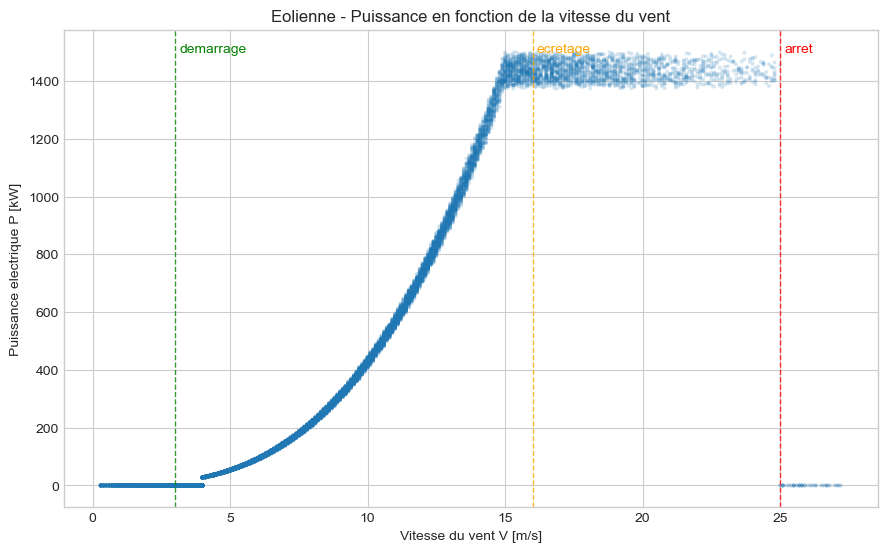

In [ ]:
fig, ax = plt.subplots(figsize=(10.5, 6.2))

ax.scatter(
    df["vitesse_vent_ms"],
    df["puissance_w"] / 1_000, # watts -> kWatts
    s=8,
    alpha=0.18,
    edgecolor="none",
)

ax.set_title("Eolienne - Puissance en fonction de la vitesse du vent")
ax.set_xlabel("Vitesse du vent V [m/s]")
ax.set_ylabel("Puissance electrique P [kW]")

ax.axvline(3, color="green", ls="--", lw=1.0, alpha=0.8)
ax.axvline(16, color="orange", ls="--", lw=1.0, alpha=0.8)
ax.axvline(25, color="red", ls="--", lw=1.0, alpha=0.8)

ax.text(3.15, ax.get_ylim()[1] * 0.95, "demarrage", color="green")
ax.text(16.15, ax.get_ylim()[1] * 0.95, "ecretage", color="orange")
ax.text(25.15, ax.get_ylim()[1] * 0.95, "arret", color="red")

plt.show()